<a href="https://colab.research.google.com/github/shoonil/Development/blob/master/ExploratoryDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels scipy -q

In [ ]:
# ============================================================
# STEP 2 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
# ============================================================
# STEP 3 — UPLOAD DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

# Replace filename if needed
df = pd.read_csv('/content/colabAnalysis_S2_UAV_Data.csv')

Saving colabAnalysis_S2_UAV_Data.csv to colabAnalysis_S2_UAV_Data (1).csv


In [ ]:
df

,pixel_id,sentinel_blue,sentinel_green,sentinel_red,sentinel_nir,polygon_ids,NDVI,GCC,Ceriops Tagal,Rhizophora Apiculata,Unidentified,Xylocarpus Granatum,Bruguiera Cylindica,Total canopy area,% Identified Area
0,P_00_00,22,38,17,107.6,"C291,C284,C281,C252,C269,C246,C247,C250,C253,C...",0.7271,0.4935,14.52,40.20,0.14,45.14,0.00,99.86,99.86
1,P_00_01,19,33,17,104.1,"C837,C839,C840,C45,C283,C284,C848,C835,C836,C8...",0.7193,0.4783,24.04,41.34,1.99,32.63,0.00,98.01,98.01
2,P_00_02,20,35,16,108.4,"C298,C299,C109,C108,C824,C1887,C985,C826,C825,...",0.7428,0.4930,42.28,17.36,2.35,38.02,0.00,97.66,97.65
3,P_00_03,20,38,17,111.1,"C300,C305,C299,C109,C108,C1886,C824,C1885,C820...",0.7345,0.5067,10.23,88.02,1.16,0.59,0.00,98.84,98.84
4,P_00_04,18,38,14,110.0,"C820,C985,C38,C43,C984,C1889,C987,C818,C801,C9...",0.7741,0.5429,29.49,58.69,0.98,3.25,7.59,99.02,99.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,P_09_05,33,55,30,115.4,"C207,C208,C1509,C205,C1510,C1504,C1511,C1514,C...",0.5872,0.4661,42.10,27.13,2.54,26.23,2.01,97.47,97.46
96,P_09_06,37,53,30,112.1,"C207,C208,C1504,C1514,C1513,C1516,C1515,C1523,...",0.5778,0.4417,77.84,17.19,0.15,0.30,4.52,99.85,99.85
97,P_09_07,37,53,25,107.0,"C1708,C6,C1664,C1665,C1679,C1663,C1680,C1666,C...",0.6212,0.4609,55.49,22.57,0.91,6.46,14.58,99.10,99.09
98,P_09_08,37,54,22,106.2,"C1644,C1643,C1639,C1652,C1642,C1640,C1641,C219...",0.6567,0.4779,61.79,30.33,1.42,5.12,1.34,98.58,98.58


In [ ]:
# ============================================================
# STEP 4 — VIEW DATA
# ============================================================

print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

  pixel_id  sentinel_blue  sentinel_green  sentinel_red  sentinel_nir  \
0  P_00_00             22              38            17         107.6   
1  P_00_01             19              33            17         104.1   
2  P_00_02             20              35            16         108.4   
3  P_00_03             20              38            17         111.1   
4  P_00_04             18              38            14         110.0   

                                         polygon_ids    NDVI     GCC  \
0  C291,C284,C281,C252,C269,C246,C247,C250,C253,C...  0.7271  0.4935   
1  C837,C839,C840,C45,C283,C284,C848,C835,C836,C8...  0.7193  0.4783   
2  C298,C299,C109,C108,C824,C1887,C985,C826,C825,...  0.7428  0.4930   
3  C300,C305,C299,C109,C108,C1886,C824,C1885,C820...  0.7345  0.5067   
4  C820,C985,C38,C43,C984,C1889,C987,C818,C801,C9...  0.7741  0.5429   

   Ceriops Tagal  Rhizophora Apiculata  Unidentified  Xylocarpus Granatum  \
0          14.52                 40.20          0.1

In [ ]:
# ============================================================
# STEP 5 — CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

In [ ]:
# ============================================================
# STEP 6 — CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
pixel_id                0
sentinel_blue           0
sentinel_green          0
sentinel_red            0
sentinel_nir            0
polygon_ids             0
NDVI                    0
GCC                     0
Ceriops Tagal           0
Rhizophora Apiculata    0
Unidentified            0
Xylocarpus Granatum     0
Bruguiera Cylindica     0
Total canopy area       0
% Identified Area       0
dtype: int64


In [ ]:
# ============================================================
# STEP 7 — DEFINE IMPORTANT VARIABLES
# ============================================================

species_cols = [
    'Ceriops Tagal',
    'Rhizophora Apiculata',
    'Xylocarpus Granatum',
    'Bruguiera Cylindica',
    'Unidentified'
]

spectral_cols = [
    'sentinel_blue',
    'sentinel_green',
    'sentinel_red',
    'sentinel_nir',
    'NDVI',
    'GCC',
    'Total canopy area',
    '% Identified Area'
]


In [ ]:
# ============================================================
# STEP 8 — BASIC DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics:")
print(df[spectral_cols + species_cols].describe())


Descriptive Statistics:
       sentinel_blue  sentinel_green  sentinel_red  sentinel_nir        NDVI  \
count     100.000000      100.000000    100.000000    100.000000  100.000000   
mean       22.810000       41.740000     18.690000    111.051000    0.713387   
std         4.220429        6.071327      3.466128      4.882364    0.039045   
min        18.000000       33.000000     13.000000    104.100000    0.554700   
25%        20.000000       37.000000     16.000000    107.575000    0.696825   
50%        21.000000       39.500000     18.000000    110.050000    0.721850   
75%        24.000000       46.000000     20.000000    113.225000    0.737950   
max        41.000000       64.000000     31.000000    125.400000    0.786400   

              GCC  Total canopy area  % Identified Area  Ceriops Tagal  \
count  100.000000         100.000000         100.000000     100.000000   
mean     0.502339          95.665700          95.665600      34.437400   
std      0.018990           4.21

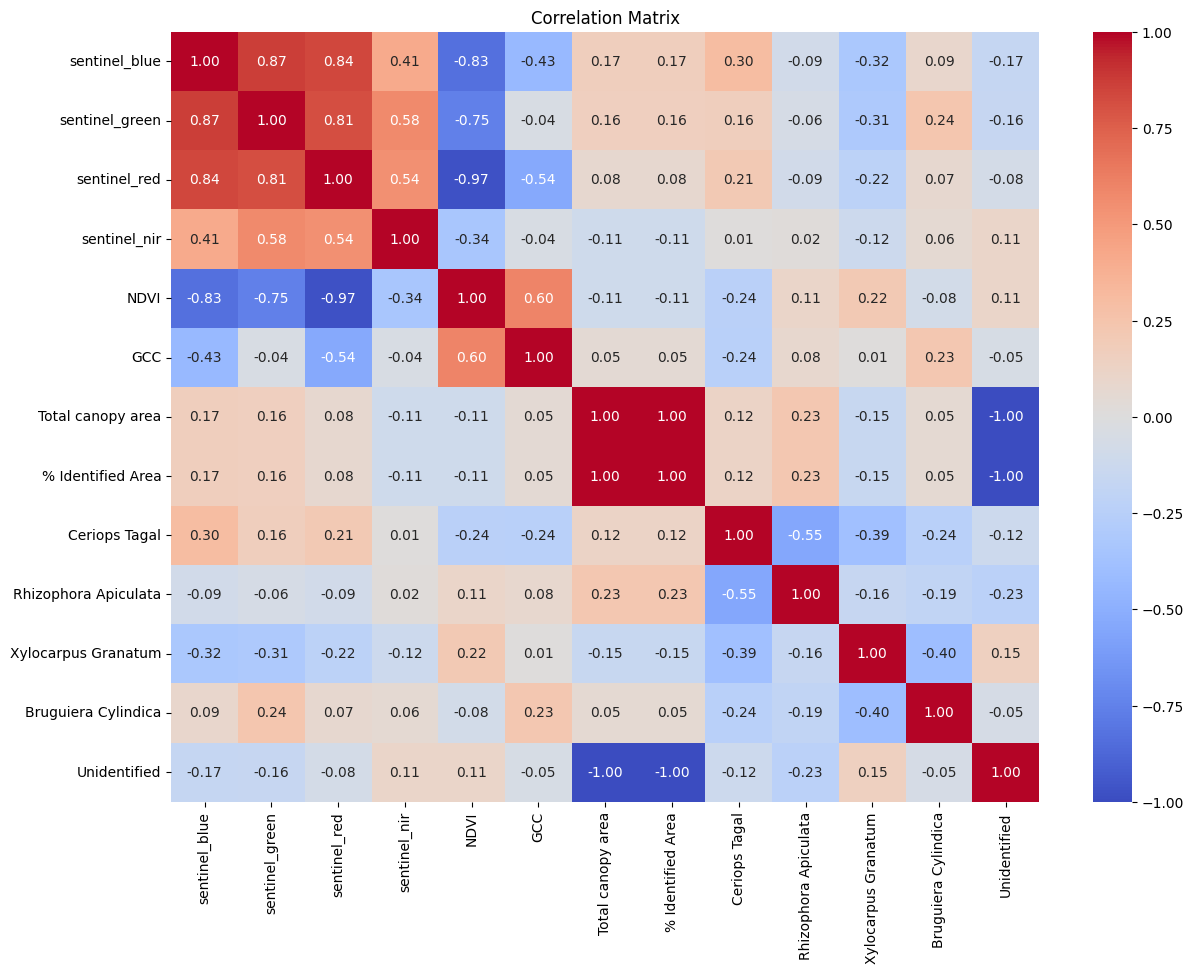

In [ ]:
# ============================================================
# STEP 9 — CORRELATION MATRIX
# ============================================================

corr_data = df[spectral_cols + species_cols]

corr_matrix = corr_data.corr(method='pearson')

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()


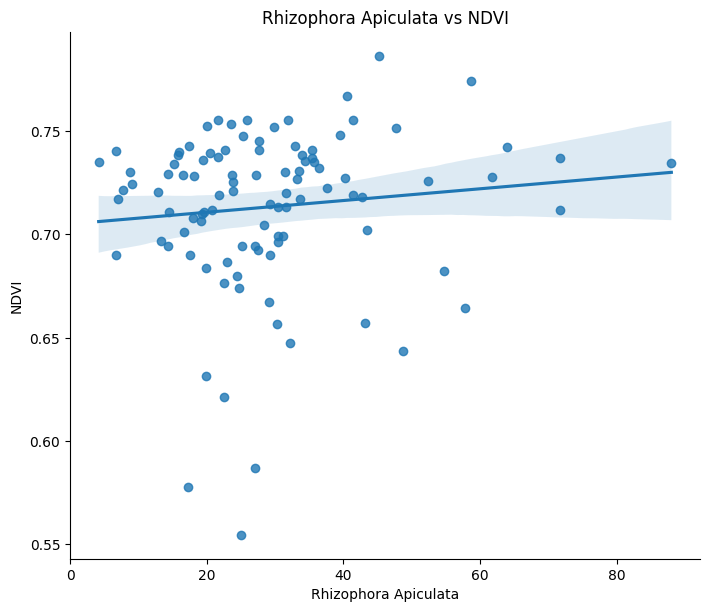

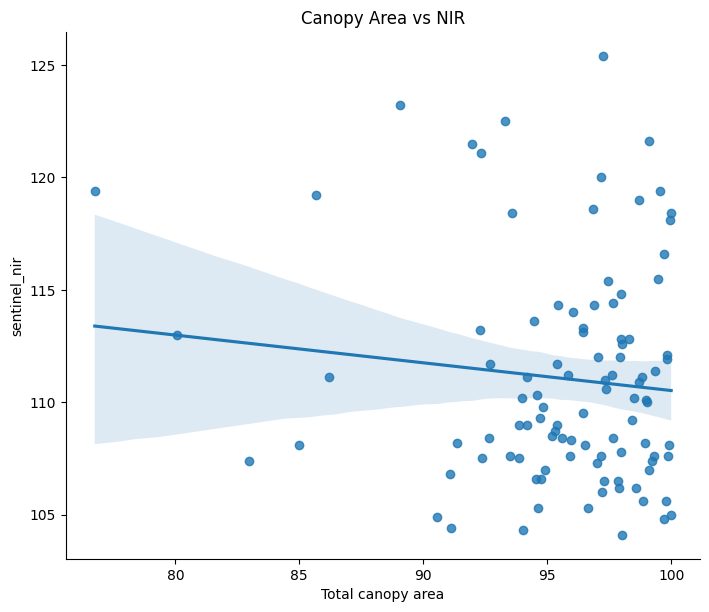

In [ ]:
# ============================================================
# STEP 10 — SCATTER PLOTS
# ============================================================

# Example relationships

sns.lmplot(
    data=df,
    x='Rhizophora Apiculata',
    y='NDVI',
    height=6,
    aspect=1.2
)

plt.title('Rhizophora Apiculata vs NDVI')
plt.show()

sns.lmplot(
    data=df,
    x='Total canopy area',
    y='sentinel_nir',
    height=6,
    aspect=1.2
)

plt.title('Canopy Area vs NIR')
plt.show()


In [ ]:
# ============================================================
# STEP 11 — PEARSON CORRELATION TESTS
# ============================================================

print("\nPearson Correlation Results")

for col in species_cols:

    r, p = pearsonr(df[col], df['NDVI'])

    print(f"\n{col}")
    print(f"Correlation with NDVI: {r:.3f}")
    print(f"P-value: {p:.5f}")


Pearson Correlation Results

Ceriops Tagal
Correlation with NDVI: -0.235
P-value: 0.01845

Rhizophora Apiculata
Correlation with NDVI: 0.109
P-value: 0.27904

Xylocarpus Granatum
Correlation with NDVI: 0.216
P-value: 0.03099

Bruguiera Cylindica
Correlation with NDVI: -0.078
P-value: 0.43780

Unidentified
Correlation with NDVI: 0.108
P-value: 0.28585


In [ ]:
# ============================================================
# STEP 12 — MULTIPLE LINEAR REGRESSION
# ============================================================

# NDVI predicted from species composition

formula = """
NDVI ~ Q('Ceriops Tagal')
+ Q('Rhizophora Apiculata')
+ Q('Xylocarpus Granatum')
+ Q('Bruguiera Cylindica')
+ Unidentified
"""

model = smf.ols(formula=formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   NDVI   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.377
Date:                Fri, 22 May 2026   Prob (F-statistic):             0.0446
Time:                        14:27:43   Log-Likelihood:                 188.87
No. Observations:                 100   AIC:                            -365.7
Df Residuals:                      94   BIC:                            -350.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

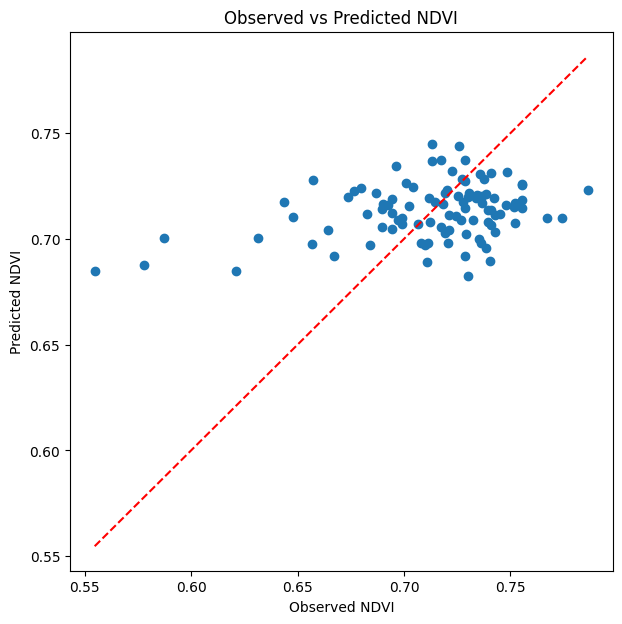

In [ ]:
# ============================================================
# STEP 13 — REGRESSION PLOT
# ============================================================

predictions = model.predict(df)

plt.figure(figsize=(7,7))

plt.scatter(df['NDVI'], predictions)

plt.xlabel('Observed NDVI')
plt.ylabel('Predicted NDVI')

plt.title('Observed vs Predicted NDVI')

plt.plot(
    [df['NDVI'].min(), df['NDVI'].max()],
    [df['NDVI'].min(), df['NDVI'].max()],
    'r--'
)

plt.show()

In [ ]:
# ============================================================
# STEP 14 — SHANNON DIVERSITY INDEX
# ============================================================

def shannon_diversity(row):

    proportions = np.array([
        row['Ceriops Tagal'],
        row['Rhizophora Apiculata'],
        row['Xylocarpus Granatum'],
        row['Bruguiera Cylindica']
    ])

    proportions = proportions / proportions.sum()

    proportions = proportions[proportions > 0]

    return -np.sum(proportions * np.log(proportions))

df['Shannon_Diversity'] = df.apply(shannon_diversity, axis=1)

print(df[['pixel_id', 'Shannon_Diversity']].head())


  pixel_id  Shannon_Diversity
0  P_00_00           1.005581
1  P_00_01           1.074978
2  P_00_02           1.036755
3  P_00_03           0.368574
4  P_00_04           0.979775


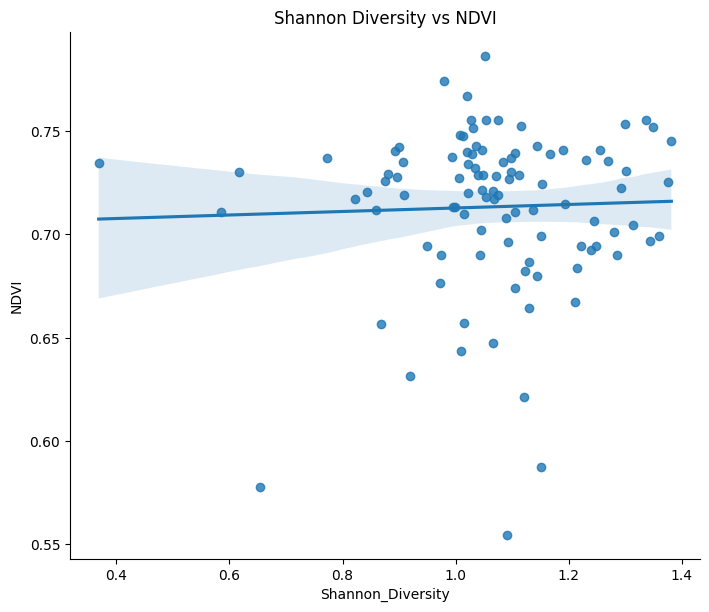

In [ ]:
# ============================================================
# STEP 15 — DIVERSITY VS NDVI
# ============================================================

sns.lmplot(
    data=df,
    x='Shannon_Diversity',
    y='NDVI',
    height=6,
    aspect=1.2
)

plt.title('Shannon Diversity vs NDVI')
plt.show()

In [ ]:
# ============================================================
# STEP 16 — DOMINANT SPECIES CLASSIFICATION
# ============================================================

def dominant_species(row):

    species = {
        'Ceriops Tagal': row['Ceriops Tagal'],
        'Rhizophora Apiculata': row['Rhizophora Apiculata'],
        'Xylocarpus Granatum': row['Xylocarpus Granatum'],
        'Bruguiera Cylindica': row['Bruguiera Cylindica']
    }

    return max(species, key=species.get)

df['Dominant_Species'] = df.apply(dominant_species, axis=1)

print(df[['pixel_id', 'Dominant_Species']].head())

  pixel_id      Dominant_Species
0  P_00_00   Xylocarpus Granatum
1  P_00_01  Rhizophora Apiculata
2  P_00_02         Ceriops Tagal
3  P_00_03  Rhizophora Apiculata
4  P_00_04  Rhizophora Apiculata


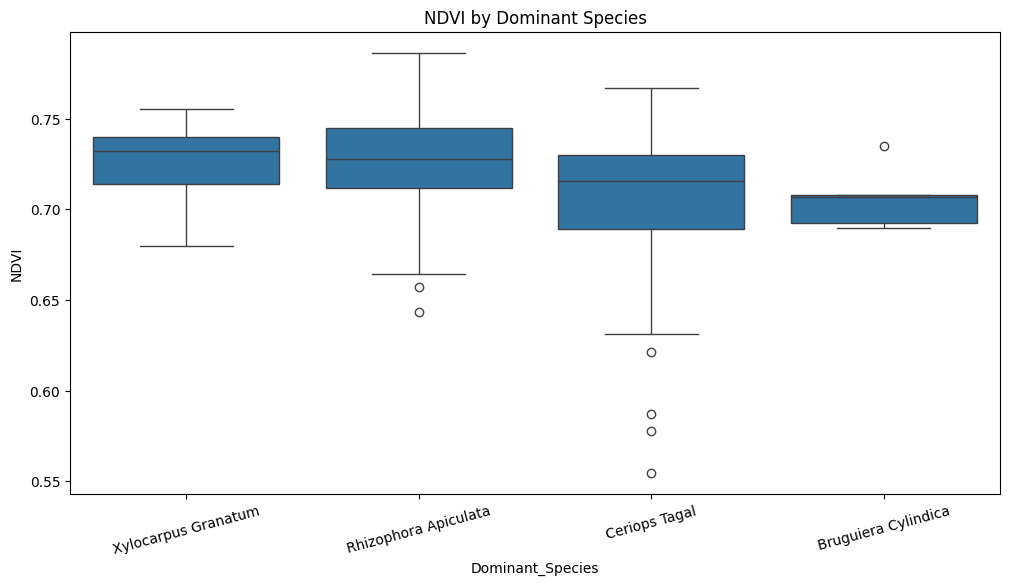

In [ ]:
# ============================================================
# STEP 17 — BOXPLOT OF NDVI BY SPECIES
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Dominant_Species',
    y='NDVI'
)

plt.xticks(rotation=15)

plt.title('NDVI by Dominant Species')

plt.show()

In [ ]:
# ============================================================
# STEP 18 — ANOVA TEST
# ============================================================

groups = []

for species in df['Dominant_Species'].unique():

    groups.append(
        df[df['Dominant_Species'] == species]['NDVI']
    )

anova_result = f_oneway(*groups)

print("\nANOVA Results")
print(anova_result)



ANOVA Results
F_onewayResult(statistic=np.float64(3.0318269914632614), pvalue=np.float64(0.033033564740878374))


In [ ]:
# ============================================================
# STEP 19 — PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================================

pca_features = spectral_cols + species_cols

X = df[pca_features]

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

pca_df['Dominant_Species'] = df['Dominant_Species']

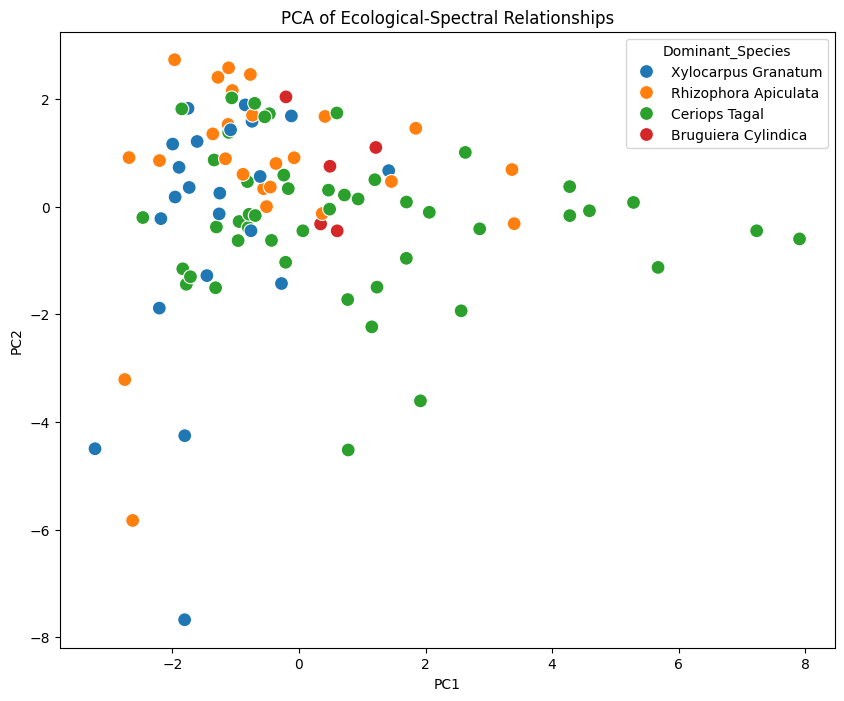

In [ ]:
# ============================================================
# STEP 20 — PCA PLOT
# ============================================================

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Dominant_Species',
    s=100
)

plt.title('PCA of Ecological-Spectral Relationships')

plt.show()

In [ ]:
# ============================================================
# STEP 21 — EXPLAINED VARIANCE
# ============================================================

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.33695638 0.23566361]


In [ ]:
# ============================================================
# STEP 22 — K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

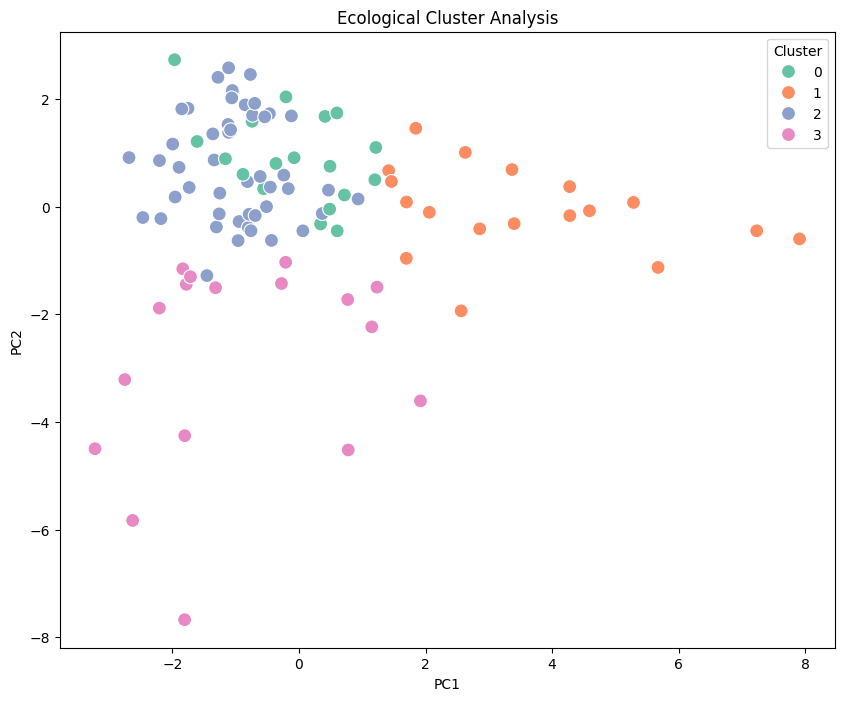

In [ ]:
# ============================================================
# STEP 23 — CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['Cluster'],
    palette='Set2',
    s=100
)

plt.title('Ecological Cluster Analysis')

plt.show()

In [ ]:
# ============================================================
# STEP 24 — SAVE RESULTS
# ============================================================

df.to_csv(
    'phase1_analysis_results.csv',
    index=False
)

print("\nAnalysis completed successfully.")
print("Results saved as phase1_analysis_results.csv")


Analysis completed successfully.
Results saved as phase1_analysis_results.csv
